In [ ]:
# Importar Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import autocorrelation_plot
from scipy import stats

In [ ]:
# Cargar archivo
transactions = pd.read_parquet('../transactions_agg.parquet') # transactions_agg (dataset sin duplicados)
segmentos = pd.read_parquet('../lakehouse/abc_xyz_segment.parquet')


In [37]:
transactions['price'] = transactions['price'] * 50000

In [38]:
segment_counts = segmentos['abc_xyz_segment'].value_counts().sort_index()

In [39]:
segment_counts

abc_xyz_segment
AX     72358
AY    308410
AZ     19818
BX    472522
BY    317691
BZ    171482
Name: count, dtype: int64

<a id='sarimax'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
SEGMENTO BX (Clientes de alto valor y estabilidad ALTA)

In [ ]:
# Leer el dataset filtrando el segmento BX
df_bx = pd.read_parquet('../lakehouse/abc_xyz_segment.parquet').query("abc_xyz_segment == 'BX'")

In [41]:
# Obtener la lista de customer_id unicos del segmento BX
bx_customer_ids =df_bx['customer_id'].unique()

In [42]:
# Filtramos las transacciones basandonos en la lista
df_clientes = transactions[transactions['customer_id'].isin(bx_customer_ids)]

In [43]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3093097 entries, 34 to 28583868
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   sales_channel_id  int64  
 4   price             float64
dtypes: float64(1), int64(2), object(2)
memory usage: 141.6+ MB


In [44]:
df_clientes

,t_dat,customer_id,article_id,sales_channel_id,price
34,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,579941002,1,990.677966
35,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,625229004,1,990.677966
36,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,629760002,1,761.864407
37,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,649356002,1,1372.033898
44,2018-09-20,00401a367c5ac085cb9d4b77c56f3edcabf25153615db9...,427114015,2,846.610169
...,...,...,...,...,...
28583863,2020-09-22,ffb72741f3bc3d98855703b55d34e05bc7893a5d6a99a3...,762846006,2,1270.338983
28583864,2020-09-22,ffb72741f3bc3d98855703b55d34e05bc7893a5d6a99a3...,762846027,2,1270.338983
28583865,2020-09-22,ffb72741f3bc3d98855703b55d34e05bc7893a5d6a99a3...,914404001,2,2117.796610
28583867,2020-09-22,ffc92c3f7b0b302f393c2968b290f6e5c5b5510d1cf1df...,740519002,2,2287.288136


In [45]:
# Agregación diaria - sumar price por fecha
df_daily = df_clientes.groupby('t_dat')['price'].sum().reset_index()
df_daily['t_dat'] = pd.to_datetime(df_daily['t_dat'])
df_daily = df_daily.sort_values('t_dat').set_index('t_dat')

In [46]:
# Dividir el train y test (ultimos 15 dias para test)
train_size = len(df_daily) - 15
train = df_daily.iloc[:train_size]
test = df_daily.iloc[train_size:]

In [47]:
print(f"\nTrain: {train.index.min()} a {train.index.max()} ({len(train)} días)")
print(f"Test: {test.index.min()} a {test.index.max()} ({len(test)} días)")


Train: 2018-09-20 00:00:00 a 2020-09-07 00:00:00 (719 días)
Test: 2020-09-08 00:00:00 a 2020-09-22 00:00:00 (15 días)


In [48]:
# Verificar estacionariedad
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

In [49]:
check_stationarity(train['price'])

ADF Statistic: -5.639307750058328
p-value: 1.045380679507146e-06
Critical Values:
	1%: -3.439580754053961
	5%: -2.865613606467485
	10%: -2.568939269723711


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Los resultados de la prueba ADF indican que la serie temporal es estacionaria:

- ADF Statistic: -5.63 (menor a los valores críticos)
- p-value: 1.04-06 (menor a 0.05)

Esto significa que no necesitamos aplicar diferenciación.

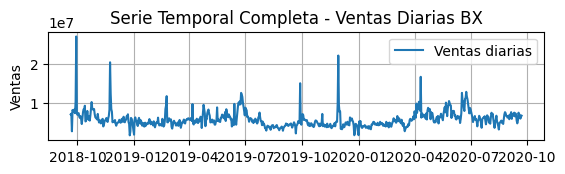

In [87]:
# Serie completa
plt.subplot(3, 1, 1)
plt.plot(df_daily.index, df_daily['price'], label='Ventas diarias')
plt.title('Serie Temporal Completa - Ventas Diarias BX')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

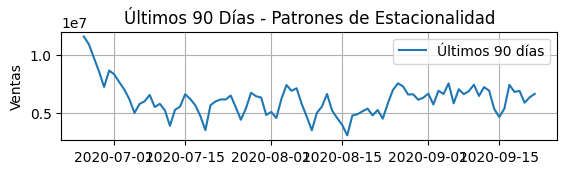

In [51]:
# Últimos 90 días para ver patrones más claros
plt.subplot(3, 1, 2)
last_90_days = df_daily.tail(90)
plt.plot(last_90_days.index, last_90_days['price'], label='Últimos 90 días')
plt.title('Últimos 90 Días - Patrones de Estacionalidad')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

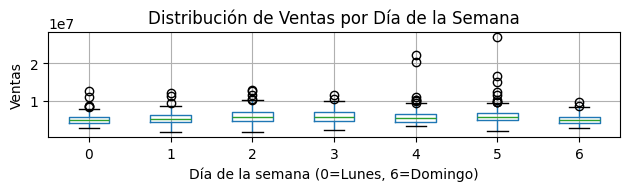

In [52]:
# Boxplot por día de la semana (para detectar estacionalidad semanal)
df_daily['day_of_week'] = df_daily.index.dayofweek
plt.subplot(3, 1, 3)
df_daily.boxplot(column='price', by='day_of_week', ax=plt.gca())
plt.title('Distribución de Ventas por Día de la Semana')
plt.suptitle('')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Ventas')

plt.tight_layout()
plt.show()

In [53]:
model = SARIMAX(train['price'], 
                order=(1, 0, 1),
                seasonal_order=(1, 0, 1, 7),
                enforce_stationarity=True,  # Ya sabemos que es estacionaria
                enforce_invertibility=False)

model_fit = model.fit(disp=False)

c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


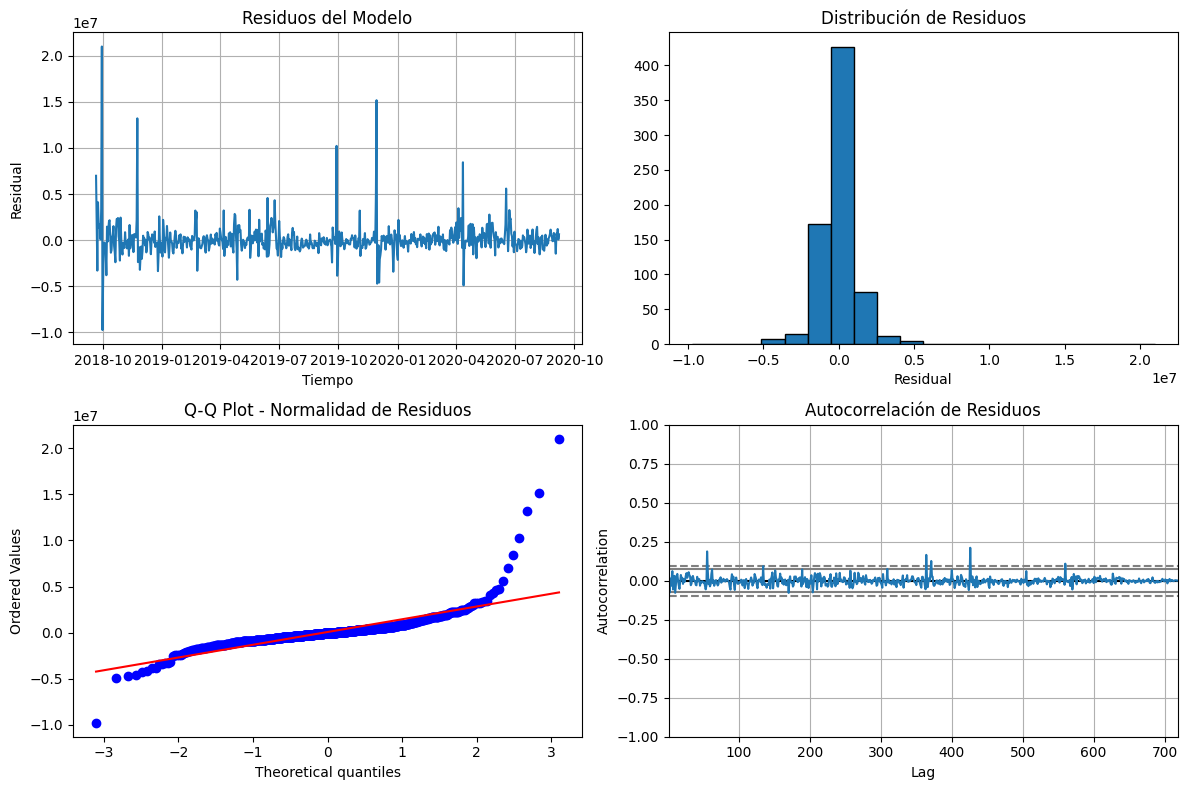

In [54]:
# Graficar residuos
residuals = model_fit.resid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(residuals)
plt.title('Residuos del Modelo')
plt.ylabel('Residual')
plt.xlabel('Tiempo')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residual')

plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalidad de Residuos')

plt.subplot(2, 2, 4)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(residuals)
plt.title('Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

In [55]:
# Pronosticar los próximos 30 días
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=train.index[-1] + pd.Timedelta(days=1), 
                              periods=forecast_steps, freq='D')

In [56]:
# Crear dataframe con las predicciones
forecast_df = pd.DataFrame({
    'predicted_mean': forecast.predicted_mean,
    'ci_lower': forecast.conf_int().iloc[:, 0],
    'ci_upper': forecast.conf_int().iloc[:, 1]
}, index=forecast_index)

In [57]:
# Crear listas separadas para cada tipo de dato
train_data = [{'date': date, 'value': price, 'type': 'train'} 
              for date, price in train['price'].items()]

test_data = [{'date': date, 'value': price, 'type': 'test'} 
             for date, price in test['price'].items()]

# Forecast futuro (solo días que no están en test)
future_forecast_dates = forecast_df.index.difference(test.index)
future_forecast_data = [{'date': date, 'value': forecast_df.loc[date, 'predicted_mean'], 'type': 'forecast_future'} 
                       for date in future_forecast_dates]

# Combinar todo
all_data = train_data + test_data + future_forecast_data

# Crear DataFrame final
consolidado = pd.DataFrame(all_data).set_index('date').sort_index().reset_index()

In [ ]:
# Guardar resultado consolidado
consolidado.to_parquet("lakehouse/forecast_BX.parquet", engine="pyarrow")

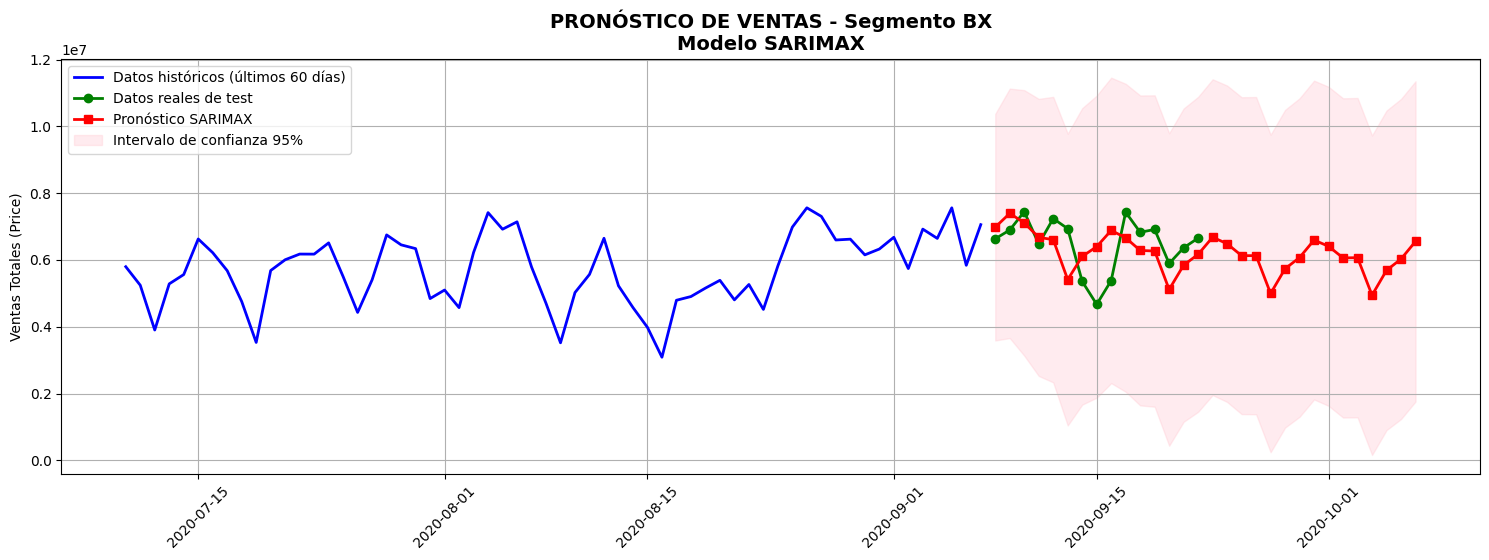

In [86]:
# VISUALIZACIÓN 
plt.figure(figsize=(15, 10))

# Serie completa con pronóstico
plt.subplot(2, 1, 1)
# Últimos 60 días del train para mejor visualización
last_60_train = train.tail(60)

plt.plot(last_60_train.index, last_60_train['price'], 
         label='Datos históricos (últimos 60 días)', color='blue', linewidth=2)
plt.plot(test.index, test['price'], 
         label='Datos reales de test', color='green', linewidth=2, marker='o')
plt.plot(forecast_df.index, forecast_df['predicted_mean'], 
         label='Pronóstico SARIMAX', color='red', linewidth=2, marker='s')
plt.fill_between(forecast_df.index, 
                forecast_df['ci_lower'], 
                forecast_df['ci_upper'], 
                color='pink', alpha=0.3, label='Intervalo de confianza 95%')

plt.title('PRONÓSTICO DE VENTAS - Segmento BX\nModelo SARIMAX', fontsize=14, fontweight='bold')
plt.ylabel('Ventas Totales (Price)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<a id='sarimax'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
SEGMENTO AX (CLIENTES MAYOR VALOR Y MAYOR ESTABILIDAD)

In [ ]:
# Filtramos segmento AX 
df_ax = pd.read_parquet('../lakehouse/abc_xyz_segment.parquet').query("abc_xyz_segment == 'AX'")

In [64]:
# Obtener ids de clientes AX
ax_customer_ids= df_ax['customer_id'].unique()

In [65]:
# Filtrado transacciones basando en los id de clientes AX
ax_df_clientes = transactions[transactions['customer_id'].isin(ax_customer_ids)]

In [66]:
ax_df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2753875 entries, 0 to 28583875
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   sales_channel_id  int64  
 4   price             float64
dtypes: float64(1), int64(2), object(2)
memory usage: 126.1+ MB


In [68]:
# Agregación diaria _ sumamos price por fecha
ax_df_daily = ax_df_clientes.groupby('t_dat')['price'].sum().reset_index()
ax_df_daily['t_dat'] = pd.to_datetime(ax_df_daily['t_dat'])
ax_df_daily = ax_df_daily.sort_values('t_dat').set_index('t_dat')

In [69]:
# Dividimos train y test (ultimos 15 dias para test)
ax_train_size = len(ax_df_daily) - 15
ax_train = ax_df_daily.iloc[:ax_train_size]
ax_test = ax_df_daily.iloc[ax_train_size:]

In [70]:
print(f"\nTrain: {ax_train.index.min()} a {ax_train.index.max()} ({len(ax_train)} días)")
print(f"Test: {ax_test.index.min()} a {ax_test.index.max()} ({len(ax_test)} días)")


Train: 2018-09-20 00:00:00 a 2020-09-07 00:00:00 (719 días)
Test: 2020-09-08 00:00:00 a 2020-09-22 00:00:00 (15 días)


In [71]:
# Verificar estacionariedad
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

In [72]:
check_stationarity(ax_train['price'])

ADF Statistic: -5.34213039453764
p-value: 4.4761756450280945e-06
Critical Values:
	1%: -3.4395677423210493
	5%: -2.8656078730509784
	10%: -2.5689362152032573


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Los resultados de la prueba ADF indican que la serie temporal es estacionaria:

- ADF Statistic: -5.34 (menor a los valores críticos)
- p-value: 4.47e-06 (menor a 0.05)

Esto significa que no necesitamos aplicar diferenciación.

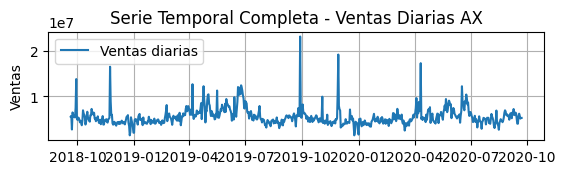

In [74]:
# Serie completa
plt.subplot(3, 1, 1)
plt.plot(ax_df_daily.index, ax_df_daily['price'], label='Ventas diarias')
plt.title('Serie Temporal Completa - Ventas Diarias AX')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

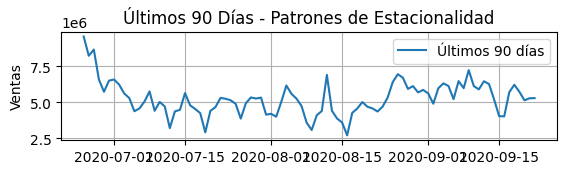

In [75]:
# Últimos 90 días para ver patrones más claros
plt.subplot(3, 1, 2)
ax_last_90_days = ax_df_daily.tail(90)
plt.plot(ax_last_90_days.index, ax_last_90_days['price'], label='Últimos 90 días')
plt.title('Últimos 90 Días - Patrones de Estacionalidad')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

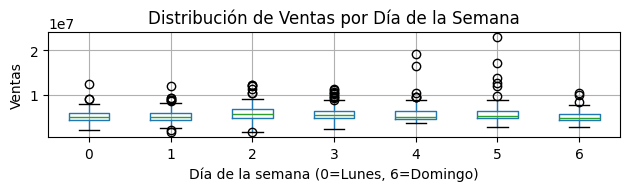

In [76]:
# Boxplot por día de la semana (para detectar estacionalidad semanal)
ax_df_daily['day_of_week'] = ax_df_daily.index.dayofweek
plt.subplot(3, 1, 3)
ax_df_daily.boxplot(column='price', by='day_of_week', ax=plt.gca())
plt.title('Distribución de Ventas por Día de la Semana')
plt.suptitle('')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Ventas')

plt.tight_layout()
plt.show()

In [ ]:
# Establece la frecuencia del índice a Diaria ('D'). Esto elimina el ValueWarning 
# en SARIMAX y es necesario si la estacionalidad (m=7) se basa en días.
# Solución de Buena Práctica
ax_train['price'] = ax_train['price'].asfreq('D')
# OR ->
# Asegúrate de que el índice es de tipo datetime
ax_train.index = pd.to_datetime(ax_train.index)

# Establece la frecuencia del índice a Diaria ('D')
ax_train = ax_train.asfreq('D')

In [108]:
ax_model = SARIMAX(ax_train['price'], 
                order=(1, 0, 1),
                seasonal_order=(1, 0, 1, 7),
                enforce_stationarity=True,  # Ya sabemos que es estacionaria
                enforce_invertibility=False)

ax_model_fit = ax_model.fit(disp=False)

c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


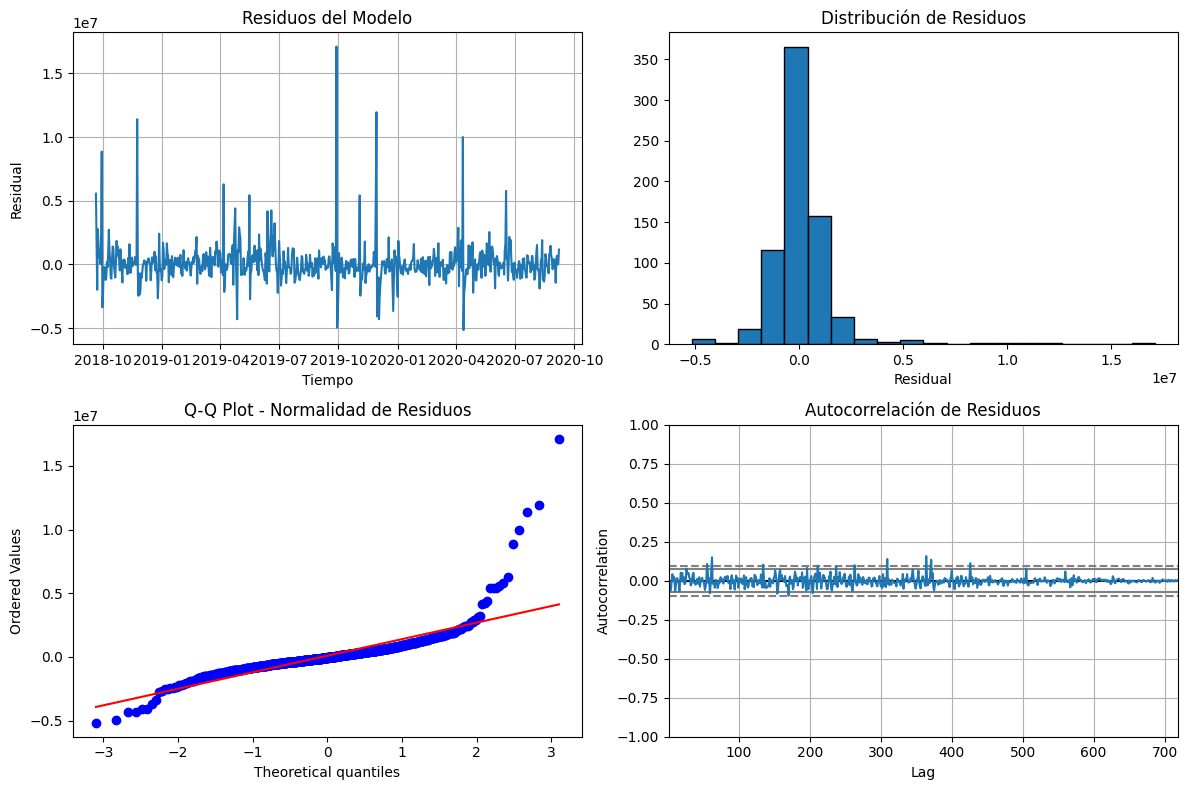

In [109]:
# Graficar residuos
ax_residuals = ax_model_fit.resid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(ax_residuals)
plt.title('Residuos del Modelo')
plt.ylabel('Residual')
plt.xlabel('Tiempo')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(ax_residuals, bins=20, edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residual')

plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(ax_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalidad de Residuos')

plt.subplot(2, 2, 4)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(ax_residuals)
plt.title('Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

In [110]:
# Pronosticar los próximos 30 días
ax_forecast_steps = 30
ax_forecast = ax_model_fit.get_forecast(steps=ax_forecast_steps)
ax_forecast_index = pd.date_range(start=ax_train.index[-1] + pd.Timedelta(days=1), 
                              periods=ax_forecast_steps, freq='D')

In [111]:
# Crear dataframe con las predicciones
ax_forecast_df = pd.DataFrame({
    'predicted_mean': ax_forecast.predicted_mean,
    'ci_lower': ax_forecast.conf_int().iloc[:, 0],
    'ci_upper': ax_forecast.conf_int().iloc[:, 1]
}, index=ax_forecast_index)

In [112]:
# Crear listas separadas para cada tipo de dato
ax_train_data = [{'date': date, 'value': price, 'type': 'train'} 
              for date, price in ax_train['price'].items()]

ax_test_data = [{'date': date, 'value': price, 'type': 'test'} 
             for date, price in ax_test['price'].items()]

# Forecast futuro (solo días que no están en test)
ax_future_forecast_dates = ax_forecast_df.index.difference(ax_test.index)
ax_future_forecast_data = [{'date': date, 'value': ax_forecast_df.loc[date, 'predicted_mean'], 'type': 'forecast_future'} 
                       for date in ax_future_forecast_dates]

# Combinar todo
ax_all_data = ax_train_data + ax_test_data + ax_future_forecast_data

# Crear DataFrame final
ax_consolidado = pd.DataFrame(ax_all_data).set_index('date').sort_index().reset_index()

In [ ]:
# Guardar resultado
ax_consolidado.to_parquet("lakehouse/forecast_AX.parquet", engine="pyarrow")

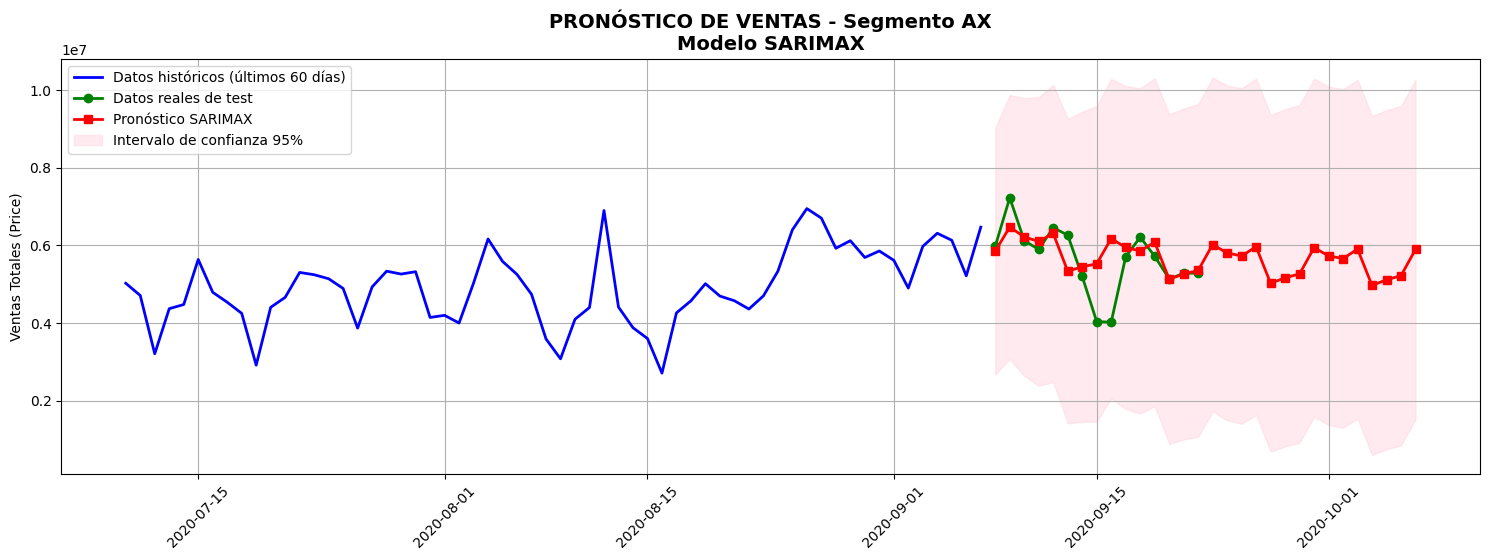

In [114]:
# VISUALIZACIÓN FINAL
plt.figure(figsize=(15, 10))

# Serie completa con pronóstico
plt.subplot(2, 1, 1)
# Últimos 60 días del train para mejor visualización
ax_last_60_train = ax_train.tail(60)

plt.plot(ax_last_60_train.index, ax_last_60_train['price'], 
         label='Datos históricos (últimos 60 días)', color='blue', linewidth=2)
plt.plot(ax_test.index, ax_test['price'], 
         label='Datos reales de test', color='green', linewidth=2, marker='o')
plt.plot(ax_forecast_df.index, ax_forecast_df['predicted_mean'], 
         label='Pronóstico SARIMAX', color='red', linewidth=2, marker='s')
plt.fill_between(ax_forecast_df.index, 
                ax_forecast_df['ci_lower'], 
                ax_forecast_df['ci_upper'], 
                color='pink', alpha=0.3, label='Intervalo de confianza 95%')

plt.title('PRONÓSTICO DE VENTAS - Segmento AX\nModelo SARIMAX', fontsize=14, fontweight='bold')
plt.ylabel('Ventas Totales (Price)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<a id='sarimax'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
SEGMENTO AY (Clientes de alto valor y estabilidad media)

In [ ]:
# Leer el dataset filtrando el segmento AY
df_ay = pd.read_parquet('../lakehouse/abc_xyz_segment.parquet').query("abc_xyz_segment == 'AY'")

In [89]:
# obtenemos la lista de customer_id únicos del segmento champions
ay_customer_ids = df_ay['customer_id'].unique()

In [90]:
# Luego filtramos las transacciones basándonos en esta lista
ay_df_clientes = transactions[transactions['customer_id'].isin(ay_customer_ids)]

In [91]:
ay_df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18319585 entries, 7 to 28583887
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   sales_channel_id  int64  
 4   price             float64
dtypes: float64(1), int64(2), object(2)
memory usage: 838.6+ MB


In [92]:
# Agregación diaria - sumar el price por fecha
ay_df_daily = ay_df_clientes.groupby('t_dat')['price'].sum().reset_index()
ay_df_daily['t_dat'] = pd.to_datetime(ay_df_daily['t_dat'])
ay_df_daily = ay_df_daily.sort_values('t_dat').set_index('t_dat')

In [93]:
# Dividir en train y test (últimos 15 días para test)
ay_train_size = len(ay_df_daily) - 15
ay_train = ay_df_daily.iloc[:ay_train_size]
ay_test = ay_df_daily.iloc[ay_train_size:]

In [94]:
print(f"\nTrain: {ay_train.index.min()} a {ay_train.index.max()} ({len(ay_train)} días)")
print(f"Test: {ay_test.index.min()} a {ay_test.index.max()} ({len(ay_test)} días)")


Train: 2018-09-20 00:00:00 a 2020-09-07 00:00:00 (719 días)
Test: 2020-09-08 00:00:00 a 2020-09-22 00:00:00 (15 días)


In [95]:
# Verificar estacionariedad
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

In [96]:
check_stationarity(ay_train['price'])

ADF Statistic: -7.430417474023756
p-value: 6.382551133640838e-11
Critical Values:
	1%: -3.43955476721974
	5%: -2.865602155751202
	10%: -2.5689331692727135


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Los resultados de la prueba ADF indican que la serie temporal es estacionaria:

- ADF Statistic: -7.43 (menor a los valores críticos)
- p-value: 6.38e-11 (menor a 0.05)

Esto significa que no necesitamos aplicar diferenciación.

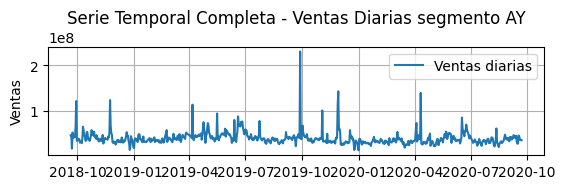

In [97]:
# Serie completa
plt.subplot(3, 1, 1)
plt.plot(ay_df_daily.index, ay_df_daily['price'], label='Ventas diarias')
plt.title('Serie Temporal Completa - Ventas Diarias segmento AY')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

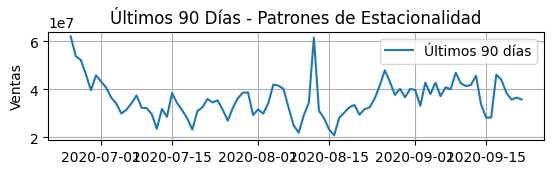

In [98]:
# Últimos 90 días para ver patrones más claros
plt.subplot(3, 1, 2)
ay_last_90_days = ay_df_daily.tail(90)
plt.plot(ay_last_90_days.index, ay_last_90_days['price'], label='Últimos 90 días')
plt.title('Últimos 90 Días - Patrones de Estacionalidad')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

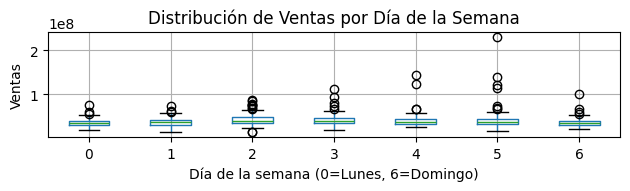

In [99]:
# Boxplot por día de la semana (para detectar estacionalidad semanal)
ay_df_daily['day_of_week'] = ay_df_daily.index.dayofweek
plt.subplot(3, 1, 3)
ay_df_daily.boxplot(column='price', by='day_of_week', ax=plt.gca())
plt.title('Distribución de Ventas por Día de la Semana')
plt.suptitle('')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Ventas')

plt.tight_layout()
plt.show()

In [ ]:
ay_model = SARIMAX(ay_train['price'], 
                order=(1, 0, 1),
                seasonal_order=(1, 0, 1, 7),
                enforce_stationarity=True,  # Ya sabemos que es estacionaria
                enforce_invertibility=False)
    
ay_model_fit = ay_model.fit(disp=False)

c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


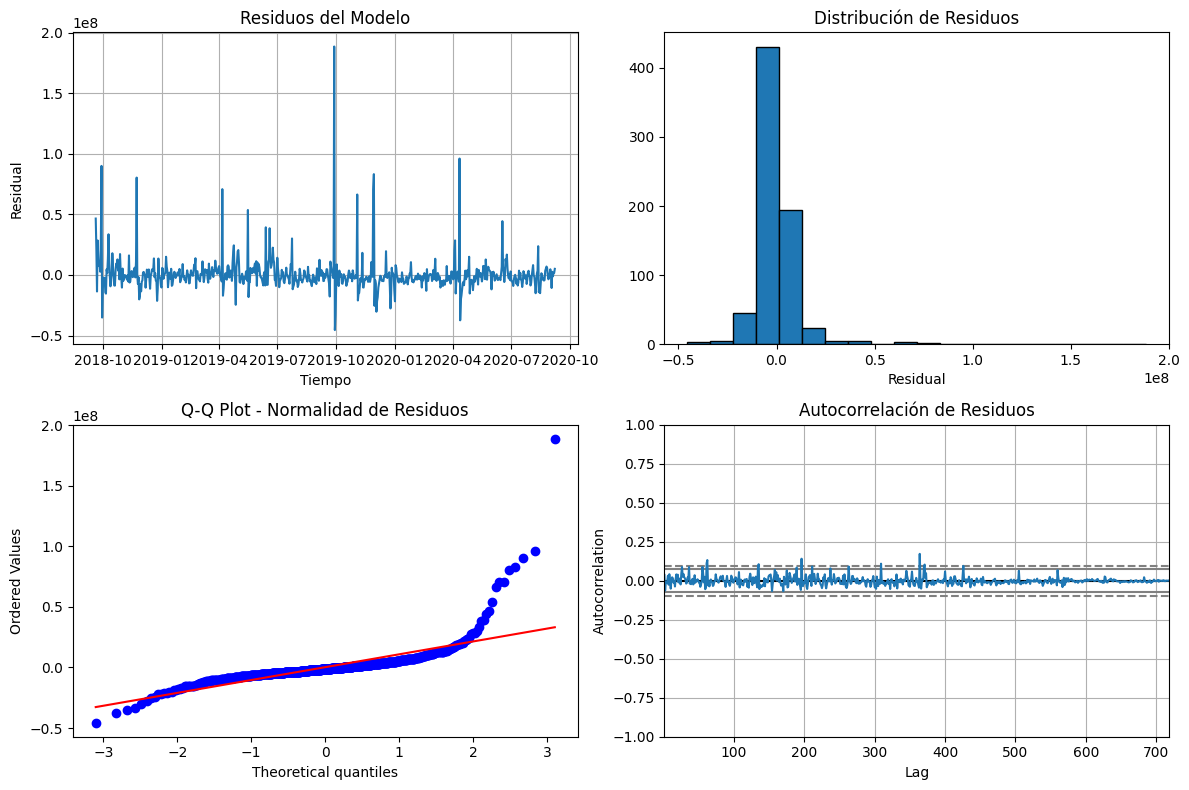

In [102]:
# Graficar residuos
ay_residuals = ay_model_fit.resid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(ay_residuals)
plt.title('Residuos del Modelo')
plt.ylabel('Residual')
plt.xlabel('Tiempo')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(ay_residuals, bins=20, edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residual')

plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(ay_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalidad de Residuos')

plt.subplot(2, 2, 4)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(ay_residuals)
plt.title('Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

In [103]:
# Pronosticar los próximos 30 días
ay_forecast_steps = 30
ay_forecast = ay_model_fit.get_forecast(steps=ay_forecast_steps)
ay_forecast_index = pd.date_range(start=ay_train.index[-1] + pd.Timedelta(days=1), 
                              periods=ay_forecast_steps, freq='D')

In [104]:
# Crear dataframe con las predicciones
ay_forecast_df = pd.DataFrame({
    'predicted_mean': ay_forecast.predicted_mean,
    'ci_lower': ay_forecast.conf_int().iloc[:, 0],
    'ci_upper': ay_forecast.conf_int().iloc[:, 1]
}, index=ay_forecast_index)

In [105]:
# Crear listas separadas para cada tipo de dato
ay_train_data = [{'date': date, 'value': price, 'type': 'train'} 
              for date, price in ay_train['price'].items()]

ay_test_data = [{'date': date, 'value': price, 'type': 'test'} 
             for date, price in ay_test['price'].items()]

# Forecast futuro (solo días que no están en test)
ay_future_forecast_dates = ay_forecast_df.index.difference(ay_test.index)
ay_future_forecast_data = [{'date': date, 'value': ay_forecast_df.loc[date, 'predicted_mean'], 'type': 'forecast_future'} 
                       for date in ay_future_forecast_dates]

# Combinar todo
ay_all_data = ay_train_data + ay_test_data + ay_future_forecast_data

# Crear DataFrame final
ay_consolidado = pd.DataFrame(ay_all_data).set_index('date').sort_index().reset_index()

In [ ]:
# Guardar resultado
ay_consolidado.to_parquet("lakehouse/forecast_AY.parquet", engine="pyarrow")

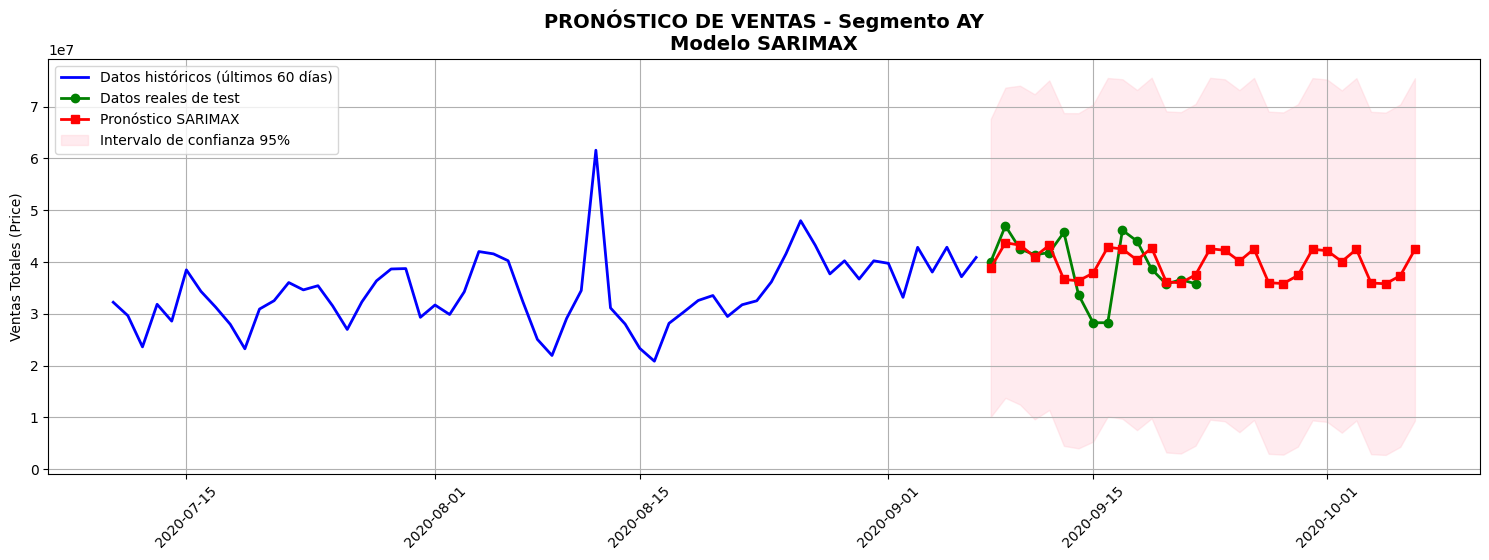

In [107]:
# VISUALIZACIÓN FINAL
plt.figure(figsize=(15, 10))

# Serie completa con pronóstico
plt.subplot(2, 1, 1)
# Últimos 60 días del train para mejor visualización
ay_last_60_train = ay_train.tail(60)

plt.plot(ay_last_60_train.index, ay_last_60_train['price'], 
         label='Datos históricos (últimos 60 días)', color='blue', linewidth=2)
plt.plot(ay_test.index, ay_test['price'], 
         label='Datos reales de test', color='green', linewidth=2, marker='o')
plt.plot(ay_forecast_df.index, ay_forecast_df['predicted_mean'], 
         label='Pronóstico SARIMAX', color='red', linewidth=2, marker='s')
plt.fill_between(ay_forecast_df.index, 
                ay_forecast_df['ci_lower'], 
                ay_forecast_df['ci_upper'], 
                color='pink', alpha=0.3, label='Intervalo de confianza 95%')

plt.title('PRONÓSTICO DE VENTAS - Segmento AY\nModelo SARIMAX', fontsize=14, fontweight='bold')
plt.ylabel('Ventas Totales (Price)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<a id='sarimax'></a>
<div style="background-color:#002147; color:white; padding:10px; border-radius:5px; font-size:18px">
SEGMENTO BY (Clientes de valor medio y estabilidad media)

In [ ]:
# Leer el dataset filtrando el segmento AY
df_by = pd.read_parquet('../lakehouse/abc_xyz_segment.parquet').query("abc_xyz_segment == 'BY'")

In [116]:
# obtenemos la lista de customer_id únicos del segmento champions
by_customer_ids = df_by['customer_id'].unique()

In [117]:
# Luego filtramos las transacciones basándonos en esta lista
by_df_clientes = transactions[transactions['customer_id'].isin(by_customer_ids)]

In [118]:
by_df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3120596 entries, 39 to 28583886
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   sales_channel_id  int64  
 4   price             float64
dtypes: float64(1), int64(2), object(2)
memory usage: 142.8+ MB


In [119]:
# Agregación diaria - sumar el price por fecha
by_df_daily = by_df_clientes.groupby('t_dat')['price'].sum().reset_index()
by_df_daily['t_dat'] = pd.to_datetime(by_df_daily['t_dat'])
by_df_daily = by_df_daily.sort_values('t_dat').set_index('t_dat')

In [120]:
# Dividir en train y test (últimos 15 días para test)
by_train_size = len(by_df_daily) - 15
by_train = by_df_daily.iloc[:by_train_size]
by_test = by_df_daily.iloc[by_train_size:]

In [121]:
print(f"\nTrain: {by_train.index.min()} a {by_train.index.max()} ({len(by_train)} días)")
print(f"Test: {by_test.index.min()} a {by_test.index.max()} ({len(by_test)} días)")


Train: 2018-09-20 00:00:00 a 2020-09-07 00:00:00 (719 días)
Test: 2020-09-08 00:00:00 a 2020-09-22 00:00:00 (15 días)


In [124]:
# Verificar estacionariedad
def by_check_stationarity(timeseries):
    by_result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {by_result[0]}')
    print(f'p-value: {by_result[1]}')
    print('Critical Values:')
    for key, value in by_result[4].items():
        print(f'\t{key}: {value}')

In [125]:
by_check_stationarity(by_train['price'])

ADF Statistic: -5.50055132637171
p-value: 2.075996752847446e-06
Critical Values:
	1%: -3.439646367660705
	5%: -2.8656425177031375
	10%: -2.5689546724554404


<div style="background-color:#9B9B9B; color:white; padding:10px; border-radius:5px; font-size:13px">
Los resultados de la prueba ADF indican que la serie temporal es estacionaria:

- ADF Statistic: -5.50 (menor a los valores críticos)
- p-value: 2.07e-06 (menor a 0.05)

Esto significa que no necesitamos aplicar diferenciación.

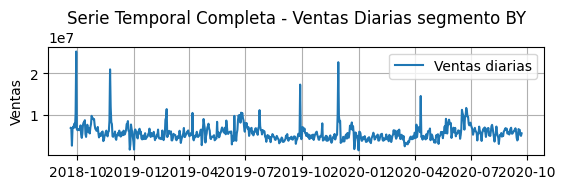

In [126]:
# Serie completa
plt.subplot(3, 1, 1)
plt.plot(by_df_daily.index, by_df_daily['price'], label='Ventas diarias')
plt.title('Serie Temporal Completa - Ventas Diarias segmento BY')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

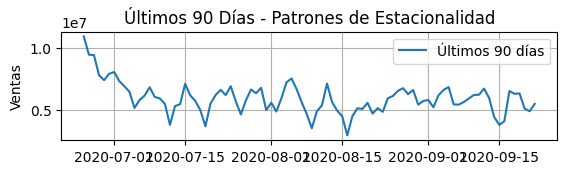

In [127]:
# Últimos 90 días para ver patrones más claros
plt.subplot(3, 1, 2)
by_last_90_days = by_df_daily.tail(90)
plt.plot(by_last_90_days.index, by_last_90_days['price'], label='Últimos 90 días')
plt.title('Últimos 90 Días - Patrones de Estacionalidad')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()

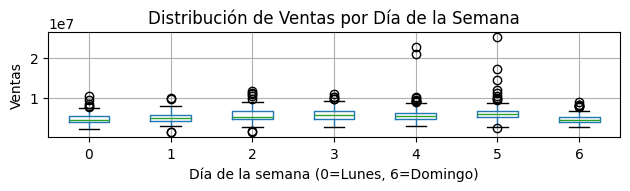

In [128]:
# Boxplot por día de la semana (para detectar estacionalidad semanal)
by_df_daily['day_of_week'] = by_df_daily.index.dayofweek
plt.subplot(3, 1, 3)
by_df_daily.boxplot(column='price', by='day_of_week', ax=plt.gca())
plt.title('Distribución de Ventas por Día de la Semana')
plt.suptitle('')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Ventas')

plt.tight_layout()
plt.show()

In [129]:
by_model = SARIMAX(by_train['price'], 
                order=(1, 0, 1),
                seasonal_order=(1, 0, 1, 7),
                enforce_stationarity=True,  # Ya sabemos que es estacionaria
                enforce_invertibility=False)

by_model_fit = by_model.fit(disp=False)

c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\wonge\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


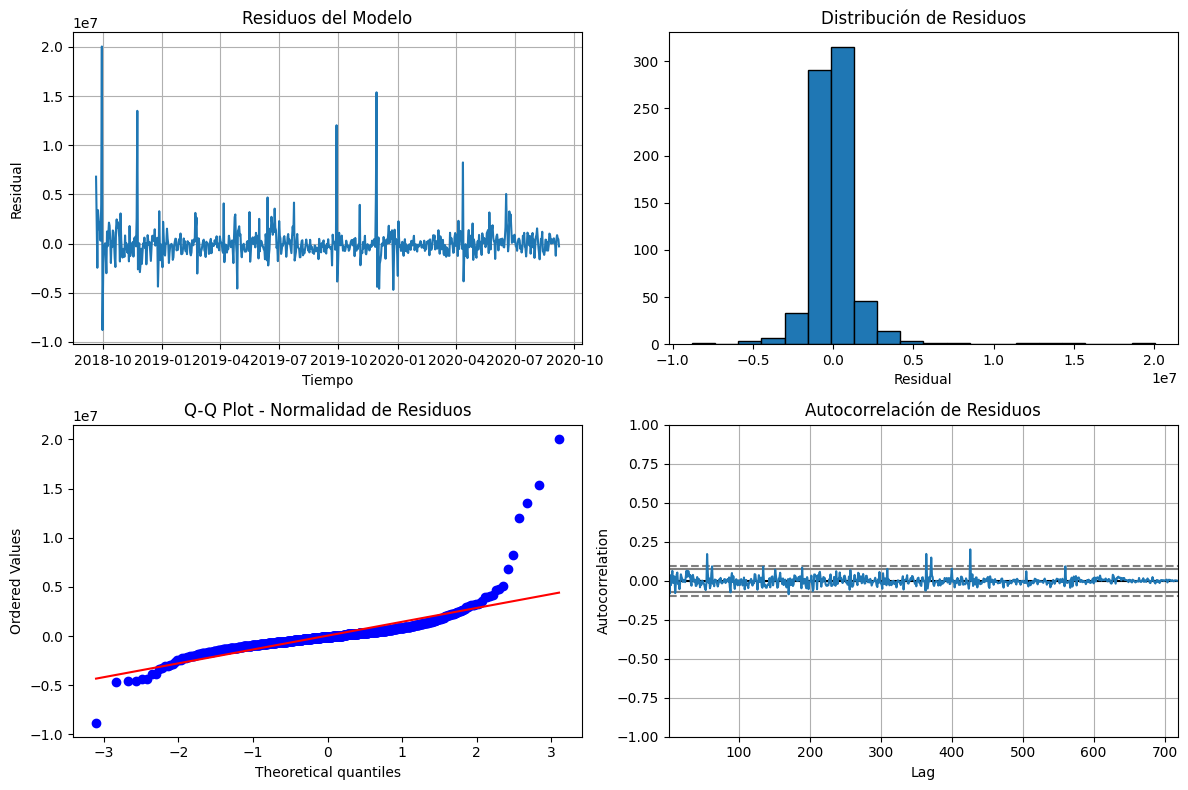

In [130]:
# Graficar residuos
by_residuals = by_model_fit.resid
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(by_residuals)
plt.title('Residuos del Modelo')
plt.ylabel('Residual')
plt.xlabel('Tiempo')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(by_residuals, bins=20, edgecolor='black')
plt.title('Distribución de Residuos')
plt.xlabel('Residual')

plt.subplot(2, 2, 3)
from scipy import stats
stats.probplot(by_residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot - Normalidad de Residuos')

plt.subplot(2, 2, 4)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(by_residuals)
plt.title('Autocorrelación de Residuos')

plt.tight_layout()
plt.show()

In [131]:
# Pronosticar los próximos 30 días
by_forecast_steps = 30
by_forecast = by_model_fit.get_forecast(steps=by_forecast_steps)
by_forecast_index = pd.date_range(start=by_train.index[-1] + pd.Timedelta(days=1), 
                              periods=by_forecast_steps, freq='D')

In [132]:
# Crear dataframe con las predicciones
by_forecast_df = pd.DataFrame({
    'predicted_mean': by_forecast.predicted_mean,
    'ci_lower': by_forecast.conf_int().iloc[:, 0],
    'ci_upper': by_forecast.conf_int().iloc[:, 1]
}, index=by_forecast_index)

In [133]:
# Crear listas separadas para cada tipo de dato
by_train_data = [{'date': date, 'value': price, 'type': 'train'} 
              for date, price in by_train['price'].items()]

by_test_data = [{'date': date, 'value': price, 'type': 'test'} 
             for date, price in by_test['price'].items()]

# Forecast futuro (solo días que no están en test)
by_future_forecast_dates = by_forecast_df.index.difference(by_test.index)
by_future_forecast_data = [{'date': date, 'value': by_forecast_df.loc[date, 'predicted_mean'], 'type': 'forecast_future'} 
                       for date in by_future_forecast_dates]

# Combinar todo
by_all_data = by_train_data + by_test_data + by_future_forecast_data

# Crear DataFrame final
by_consolidado = pd.DataFrame(by_all_data).set_index('date').sort_index().reset_index()

In [134]:
by_consolidado.to_parquet("lakehouse/forecast_BY.parquet", engine="pyarrow")

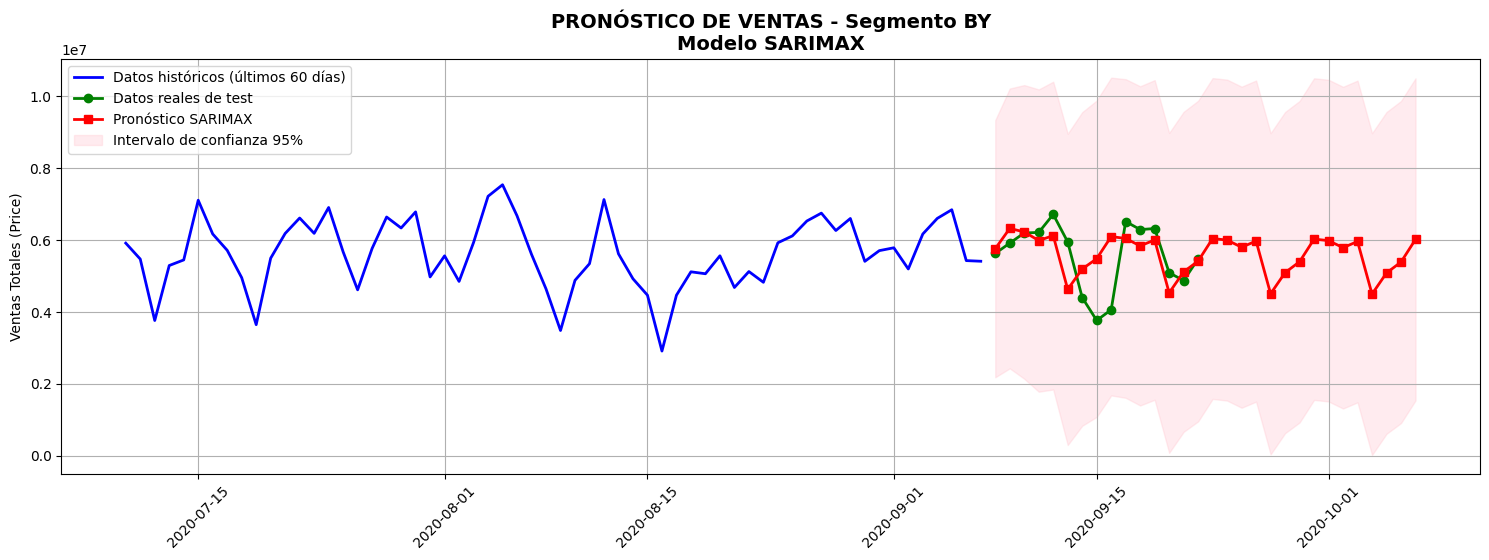

In [135]:
# VISUALIZACIÓN FINAL
plt.figure(figsize=(15, 10))

# Serie completa con pronóstico
plt.subplot(2, 1, 1)
# Últimos 60 días del train para mejor visualización
by_last_60_train = by_train.tail(60)

plt.plot(by_last_60_train.index, by_last_60_train['price'], 
         label='Datos históricos (últimos 60 días)', color='blue', linewidth=2)
plt.plot(by_test.index, by_test['price'], 
         label='Datos reales de test', color='green', linewidth=2, marker='o')
plt.plot(by_forecast_df.index, by_forecast_df['predicted_mean'], 
         label='Pronóstico SARIMAX', color='red', linewidth=2, marker='s')
plt.fill_between(by_forecast_df.index, 
                by_forecast_df['ci_lower'], 
                by_forecast_df['ci_upper'], 
                color='pink', alpha=0.3, label='Intervalo de confianza 95%')

plt.title('PRONÓSTICO DE VENTAS - Segmento BY\nModelo SARIMAX', fontsize=14, fontweight='bold')
plt.ylabel('Ventas Totales (Price)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()